# 202.5. Pixel mask planes

<div style="max-width:300px; float: left; margin-right: 1em">

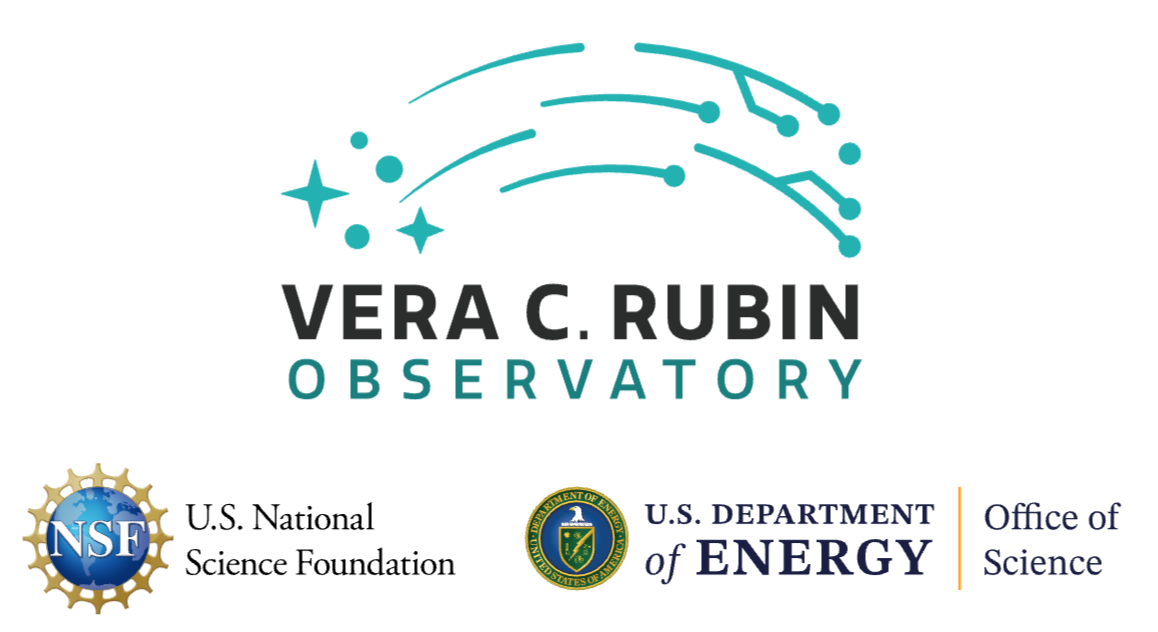

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 2](https://dp2.lsst.io/)\
Container Size: Large\
LSST Science Pipelines version: r30.0.11\
Last verified to run: 2026-09-03\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** To understand and visualize the pixel mask planes in DP2 `deep_coadd` images.

**LSST data products:** `deep_coadd`

**Packages:** `lsst.daf.butler`, `lsst.afw.display`, `lsst.images`

**Credit:**
Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the
<a href="https://community.lsst.org/c/support/6">Support Category</a>
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

In the LSST Science Pipelines, each processed image includes not only the measured flux values but also a companion bit mask image that records the condition of every pixel.
These mask planes encode information about detector defects, cosmic rays, saturation, missing data, and other effects that influence data quality.
Each named mask plane corresponds to a specific bit that can be set independently or in combination with others on a given pixel.

For example, if bit 1 corresponds to a saturated pixel (`SATURATED`) and bit 3 to a pixel that has been hit by a cosmic ray (`COSMIC_RAY`), a pixel with a mask value of 10 in binary indicates that both `SATURATED` and `COSMIC_RAY` planes are active for that pixel (i.e., $2^1 + 2^3 = 10$, see Section 3.3).
This compact representation makes it easy to test or combine conditions with bitwise operations.

This tutorial introduces the concept of mask planes in the LSST Science Pipelines and explains how to interpret them in Data Preview 2 (DP2) `deep_coadd` images.
It also demonstrates how to visualize mask information, showing how colors correspond to specific mask planes, and how to use this information to assess image quality and understand the provenance of masked regions in the data.

DP2 images use the new `lsst.images` format, in which the mask plane names and descriptions are stored in the mask's `schema` and read at runtime (Section 3.2).
Several plane names differ from the legacy `lsst.afw.image` names used in Data Preview 1 (DP1), e.g., `SAT` becomes `SATURATED`, `CR` becomes `COSMIC_RAY`, `INTRP` becomes `INTERPOLATED`, and `EDGE` becomes `DETECTION_EDGE`.

**Related tutorials:** Image tutorials in the 200 series.

### 1.1. Import packages

From the LSST Science Pipelines import the packages for the Butler and for image display.

In [ ]:
from lsst.daf.butler import Butler
import lsst.afw.display as afwDisplay
import numpy as np
import matplotlib.pyplot as plt

### 1.2. Define parameters and functions

Create an instance of the Rubin data Butler for the `dp2` repository and its default `dp2` collection.

In [ ]:
butler = Butler("dp2", collections="dp2")

Set `afwDisplay` to use `Firefly`, and open the Firefly display tab.

In [ ]:
afwDisplay.setDefaultBackend('firefly')
afw_display = afwDisplay.Display(frame=1)

## 2. Descriptions

The DP2 `deep_coadd` images are cell-based coadds, so each plane corresponds to a bit in the coadd mask that reflects the propagation or summary of pixel conditions from the contributing single-visit exposures.

Table 1 summarizes the mask planes present in the DP2 `deep_coadd` mask schema, in bit order.
Because DP2 images use the new `lsst.images` format, several plane names differ from the legacy `lsst.afw.image` names used in DP1; the legacy name is given in parentheses where it differs.

Table 1 also gives general, conservative guidance for how to treat each plane in image analysis or source measurement; the appropriate treatment depends strongly on the science case, and the pipelines may set some planes without using them downstream.

- **Exclude:** Generally indicates unusable data; these pixels should be removed.
- **Retain:** Typically propagated by the pipelines without discarding the data; usually safe to keep.
- **Conditional:** Use depends on the science case; some algorithms downweight or ignore these planes, but they are not universally excluded.

For the coadd-based `Object` catalog, the corresponding quality cuts act on the `pixelFlags_*` columns; see the DP2 documentation on flag definitions and recommendations.

| **Mask Plane** | **Legacy Name** | **Recommended Use** | **Description** |
|:---------------|:----------------|:--------------------|:----------------|
| **NO_DATA** | `NO_DATA` | Exclude | No data were available for this pixel; common at tract/patch edges, in areas not covered by any input visit, or where all inputs were masked (`SATURATED` is often a reason for `NO_DATA`). These pixels should be ignored in analysis. |
| **INTERPOLATED** | `INTRP` | Retain | The pixel value is the result of interpolating nearby good pixels; generally fine for most analyses. |
| **COSMIC_RAY** | `CR` | Retain | A cosmic ray affected this pixel on at least one input image (and was interpolated over); no need to remove unless studying extremely rare or peculiar sources. |
| **SATURATED** | `SAT` | Exclude | More than 10% of the potential input visits had a saturated pixel at this location. `SATURATED` always implies `REJECTED`, and is often a reason for `NO_DATA`. |
| **DETECTION_EDGE** | `EDGE` | Conditional | Pixel was too close to the edge of the patch to be considered for detection, due to the finite size of the detection kernel. This column is deprecated on the `Object` table. |
| **CLIPPED** | `CLIPPED` | Conditional | The region was identified as a probable artifact when comparing multiple single-visit warps, and was excluded from the coadd at this pixel. `CLIPPED` always implies `REJECTED`. |
| **REJECTED** | `REJECTED` | Conditional | At least one input visit was left out of the coadd for this pixel due to masking. `REJECTED` always implies `INEXACT_PSF`. |
| **DETECTED** | `DETECTED` | Retain | Pixel was part of a detected source footprint on the coadd (informational, not a quality flag). |
| **INEXACT_PSF** | `INEXACT_PSF` | Conditional | The set of visits contributing to this pixel differs from the set contributing to the PSF model for its cell, so the PSF at this pixel may be inexact. Because `REJECTED` implies `INEXACT_PSF`, this bit covers a large fraction of the coadd and is **not** recommended as a general quality cut. |

> **Table 1:** Mask planes in the DP2 `deep_coadd` (cell coadd) images, with general guidance for their use.

## 3. Deep coadd mask

Query for `deep_coadd` images that overlap the coordinates RA, Dec (in degrees) near the center of the Extended Chandra Deep Field South (ECDFS) field, obtained with the r-band filter.

In [ ]:
ra = 53.076
dec = -28.110
band = 'r'
dataset_refs = butler.query_datasets("deep_coadd",
                                     where="band.name = :band AND \
                                     patch.region OVERLAPS POINT(:ra, :dec)",
                                     bind={"band": band, "ra": ra, "dec": dec})
print(len(dataset_refs))
del ra, dec, band

For the first dataset reference returned by the query, get the corresponding `deep_coadd`.

In [ ]:
ref = dataset_refs[0]
deep_coadd = butler.get(ref)

### 3.1. Get the mask plane

Extract the `mask` plane from the `deep_coadd`.
In the new `lsst.images` format the mask is accessed as the `.mask` attribute (rather than the `getMask()` method used by the older `lsst.afw.image` format).

In [ ]:
mask = deep_coadd.mask

### 3.2. Print the mask schema

In the new image format, the mask plane definitions (names, bit assignments, and descriptions) are stored in the mask's `schema`, which is read at runtime.
This is the authoritative list of the planes present in this image.

Print the mask `schema`.

> **Warning:** Bit values are assigned dynamically and are not guaranteed to be fixed between data releases.

In [ ]:
mask.schema

### 3.3. Interpret the mask values

Mask planes in the LSST Science Pipelines use a *bitmask representation*: each mask plane corresponds to one **bit**, which records whether a particular condition is **True (1)** or **False (0)** for a given pixel.
Multiple planes can be set on the same pixel by raising more than one bit.

The `schema` printed above lists, for each plane, its overall **Bit** number, the array **Index** and **Mask** used to store it, and a **Description**.
In the new `lsst.images` format the mask is stored as a bit-packed array (Section 3.4), so a single pixel is represented by a short one-dimensional array of bytes rather than a single integer.

The `schema` provides an `interpret` method that returns the names of all planes set on a given pixel value.
Find the pixel with the largest number of planes set, and interpret its value.

In [ ]:
n_set = np.zeros(mask.bbox.shape, dtype=int)
for name in mask.schema.names:
    n_set += mask.get(name)

y, x = np.unravel_index(np.argmax(n_set), n_set.shape)
print(f"Pixel (x={x}, y={y}) has {n_set[y, x]} planes set: ")
print(mask.schema.interpret(mask.array[y, x]))

### 3.4. Check the values in the mask array

List the unique pixel-value combinations in the mask, the number of pixels with each combination, and the planes that each combination represents.
Because the mask is bit-packed, reshape the array so that each row is one pixel's value, then find the unique rows.

In [ ]:
pixel_values = mask.array.reshape(-1, mask.schema.mask_size)
combos, counts = np.unique(pixel_values, axis=0, return_counts=True)

print(f"{'Counts': <10} {'Mask planes'}")
print("-" * 60)
for combo, count in zip(combos, counts):
    print(f"{count: <10} {mask.schema.interpret(combo)}")

Print the number of pixels with each individual plane set.
Planes with a count of zero are defined in the schema but are not populated in this image.

In [ ]:
for plane in mask.schema:
    if plane is not None:
        print(f"{plane.name: <16} {np.sum(mask.get(plane.name))}")

### 3.5. Extract a specific plane

Individual mask planes are extracted with the `get` method, which returns a two-dimensional boolean array that is `True` where that plane's bit is set.

Calculate the fraction of pixels flagged as cosmic rays (`COSMIC_RAY`).

In [ ]:
cr_mask = mask.get("COSMIC_RAY")
print("Fraction of pixels flagged as COSMIC_RAY:", np.mean(cr_mask))

### 3.6. Display with Firefly

Display the `deep_coadd` in frame 1, and set the mask transparency to 0 (opaque, to show the mask).
With the mask fully opaque, a large fraction of the pixels will be colored (have a nonzero mask value).

In [ ]:
afw_display = afwDisplay.Display(frame=1)
afw_display.image(deep_coadd)
afw_display.setMaskTransparency(0)

Display the mask by itself in Firefly frame 2.

In [ ]:
afw_display = afwDisplay.Display(frame=2)
afw_display.image(mask)

<div style="max-width:400px; float: left; margin-right: 1em">

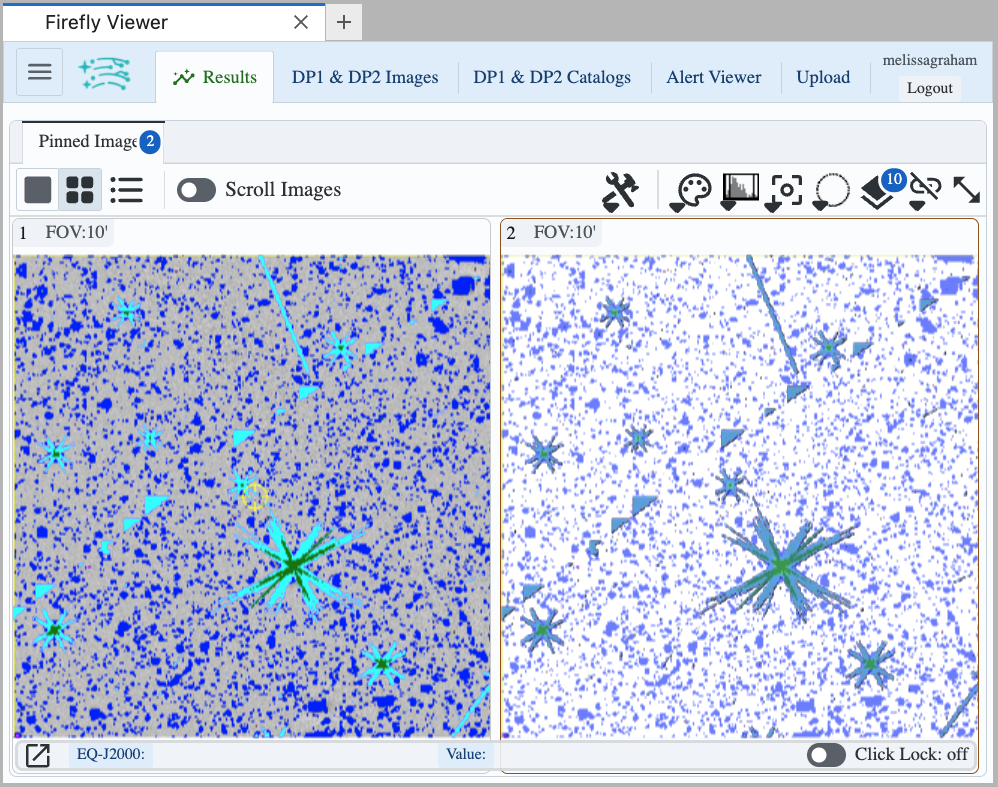

</div>

>**Figure 1:** A screenshot of what the Firefly window should look like at this point: the deep coadd image with the mask overlay (left) and the mask displayed by itself (right).

The colors differ from frame 1 because the Firefly display interprets the pixel values as flux values (mouse-over in the Firefly window to see).
The coordinates ("WCS") are in pixels, and the values ("Flux") are the combined integer bit values per pixel (although in this case they do not represent a physical flux).

Set the mask transparency to opaque to match the colors in frame 1.

In [ ]:
afw_display.setMaskTransparency(0)

Set all mask plane names to transparent except the `DETECTED` plane, and display again in frame 1.

In [ ]:
afw_display = afwDisplay.Display(frame=1)
afw_display.setMaskTransparency(100)
afw_display.setMaskTransparency(0, 'DETECTED')

### 3.7. Display with Matplotlib

Mask objects are **bitmasks**, not booleans: each bit encodes a different mask plane, so plotting the raw mask array directly with `matplotlib` can be misleading.
Instead, extract each plane with the `get` method (Section 3.5), which returns a boolean array, and plot the planes individually.

In [ ]:
planes = [plane.name for plane in mask.schema if plane is not None]

n_col = 5
n_row = int(np.ceil(len(planes) / n_col))

fig = plt.figure(figsize=(12, 3 * n_row))
for i, name in enumerate(planes):
    fig.add_subplot(n_row, n_col, i + 1)
    plt.imshow(mask.get(name), vmin=0, vmax=1,
               origin='lower', cmap='Greys',
               interpolation='nearest')
    plt.title(name)
    plt.axis('off')
plt.show()

> **Figure 2:** Individual mask plane arrays for the `deep_coadd`, displayed with `matplotlib`.

Clean up.

In [ ]:
del mask, n_set, y, x, pixel_values, combos, counts, cr_mask, planes
del ref, deep_coadd, dataset_refs